In [1]:
import re
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

ROOT_PATH = Path().resolve().parents[3]
sys.path.insert(0, str(ROOT_PATH))


In [2]:
NU_CKPT = ROOT_PATH / (
    "experiments/numu/"
    "260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32/"
    "best_da_model.pth"
)

# ── Data ──────────────────────────────────────────────────────────────
EXP_H5 = ROOT_PATH / "data_manager/data/h5datasets/exp.h5"
# ── Devices ───────────────────────────────────────────────────────────
DEVICE_SN = "cuda:1"
DEVICE_NU = "cuda:1"

# ── Inference params ──────────────────────────────────────────────────
SN_THRESHOLD   = 0.8
NU_THR = 0.8
MIN_SN_HITS    = 8
MIN_SN_STRINGS = 2
BATCH_SIZE     = 512

# ── Cap: set to an int to test on a subset of parts, None = all ───────
N_PARTS_CAP = None

# ── Broken OM blacklist ───
APPLY_BLACKLIST = True
BLACKLIST = [
    {"channel": 198, "part_key": "part_s2020_c04_r0117"},  # broken OM, single run
    {"channel":  71, "cluster": 4},                         # broken OM, all cluster 4
]

STRING_DIVISOR = 36

In [3]:
from inference_v2.shared.model_utils import load_model, load_sn_model, predict_scores
from gplotnikov_sig_noise_models.k_nsol_labelneq0_da_hs128_k0p0001.sig_noise_model_v3 import (
    predict_flat as _sn_predict_flat,
)
from data_manager.nu_classifier_ds_builder.io import _count_sig_hits_strings

print("Loading SN model ...")
_sn_nn, _sn_cfg, _sn_dev = load_sn_model(device=DEVICE_SN)

print("Loading nu-classifier model ...")
nu_model, nu_norm, nu_cfg = load_model(str(NU_CKPT), device=DEVICE_NU)
nu_max_hits   = nu_cfg.get("data", {}).get("max_hits", 500)
nu_with_probs = nu_cfg.get("model", {}).get("input_dim", 5) == 6
print(f"  nu-classif max_hits={nu_max_hits}  with_probs={nu_with_probs}")

print("\nAll models loaded.")

Loading SN model ...


/home/albert/Baikal2025/gplotnikov_sig_noise_models/k_nsol_labelneq0_da_hs128_k0p0001/model_simplified.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.enc = nn.TransformerEncoder(enc_layer, num_layers)


Loading nu-classifier model ...
  nu-classif max_hits=500  with_probs=False

All models loaded.


In [4]:
# ── Helpers ───────────────────────────────────────────────────────────
_PART_RE = re.compile(r"part_s(\d+)_c(\d+)_r(\d+)")

def _parse_part_key(pk: str) -> tuple[int, int, int]:
    m = _PART_RE.match(pk)
    return int(m.group(1)), int(m.group(2)), int(m.group(3))

def _make_blacklist_mask(channels: np.ndarray, cluster: int, part_key: str) -> np.ndarray:
    """Return per-hit boolean keep-mask for the current part."""
    if not APPLY_BLACKLIST:
        return np.ones(len(channels), dtype=bool)
    mask = np.ones(len(channels), dtype=bool)
    for rule in BLACKLIST:
        ch = rule["channel"]
        if "part_key" in rule and part_key == rule["part_key"]:
            mask &= channels != ch
        elif "cluster" in rule and cluster == rule["cluster"]:
            mask &= channels != ch
    return mask

# ── Main processing loop ──────────────────────────────────────────────
records = []

with h5py.File(str(EXP_H5), "r") as h5f:
    grp   = h5f["exp"]
    parts = sorted(grp["raw"]["data"].keys())
    if N_PARTS_CAP is not None:
        parts = parts[:N_PARTS_CAP]
    print(f"Processing {len(parts)} parts ...")

    for pk in tqdm(parts, desc="parts"):
        ev_starts = grp[f"raw/ev_starts/{pk}/data"][:].astype(np.int64)
        n_events  = len(ev_starts) - 1
        if n_events == 0:
            continue

        data_raw = grp[f"raw/data/{pk}/data"][:].astype(np.float32)
        channels = grp[f"raw/channels/{pk}/data"][:].astype(np.int32)

        season, cluster, run_num = _parse_part_key(pk)

        # ── Apply blacklist (part-level, vectorised) ───────────────────
        bl_mask = _make_blacklist_mask(channels, cluster, pk)
        clean_raw   = data_raw[bl_mask]
        clean_chans = channels[bl_mask]

        # Recompute per-event clean hit counts via cumsum trick
        bl_cum        = np.concatenate([[0], np.cumsum(bl_mask)])
        clean_hit_cnt = (bl_cum[ev_starts[1:]] - bl_cum[ev_starts[:-1]]).astype(np.int32)
        clean_starts  = np.concatenate([[0], np.cumsum(clean_hit_cnt.astype(np.int64))]).astype(np.int64)

        # ── SN model on clean raw hits ─────────────────────────────────
        if len(clean_raw) == 0:
            n_sn_h = np.zeros(n_events, dtype=np.int32)
            n_sn_s = np.zeros(n_events, dtype=np.int32)
        else:
            sn_probs = _sn_predict_flat(
                _sn_nn, clean_raw, clean_starts,
                batch_size=BATCH_SIZE, device=torch.device(_sn_dev),
                normalize=True, desc="",
            )
            sn_mask = sn_probs >= SN_THRESHOLD
            n_sn_h, n_sn_s = _count_sig_hits_strings(
                sn_mask, clean_chans,
                clean_starts[:-1].astype(np.int64),
                clean_hit_cnt, n_events,
            )

        # ── Nu-classifier: original z and z-inverted ───────────────────
        nu_eligible         = np.where((n_sn_h >= MIN_SN_HITS) & (n_sn_s >= MIN_SN_STRINGS))[0]
        nu_scores_part      = np.full(n_events, np.nan, dtype=np.float32)
        nu_scores_part_zinv = np.full(n_events, np.nan, dtype=np.float32)

        if len(nu_eligible) > 0:
            nu_feats = []
            for ei in nu_eligible:
                s, e    = int(clean_starts[ei]), int(clean_starts[ei + 1])
                ev_mask = sn_mask[s:e]
                nu_feats.append(clean_raw[s:e][ev_mask])

            nu_scores_part[nu_eligible] = predict_scores(
                nu_model, nu_feats, nu_norm,
                batch_size=BATCH_SIZE, max_hits=nu_max_hits,
                device=DEVICE_NU, feats_with_probs=nu_with_probs,
                with_tqdm=False,
            )

            # z-inversion: copy each array, negate column 4, leave nu_feats intact
            nu_feats_zinv = []
            for feat in nu_feats:
                zinv = feat.copy()
                zinv[:, 4] = -zinv[:, 4]
                nu_feats_zinv.append(zinv)

            nu_scores_part_zinv[nu_eligible] = predict_scores(
                nu_model, nu_feats_zinv, nu_norm,
                batch_size=BATCH_SIZE, max_hits=nu_max_hits,
                device=DEVICE_NU, feats_with_probs=nu_with_probs,
                with_tqdm=False,
            )

        # ── Collect SN-quality events only ────────────────────────────
        for ei in nu_eligible:
            records.append({
                "part_key":      pk,
                "local_idx":     int(ei),
                "season":        season,
                "cluster":       cluster,
                "run_num":       run_num,
                "n_raw_hits":    int(clean_hit_cnt[ei]),
                "n_sn_hits":     int(n_sn_h[ei]),
                "n_sn_strings":  int(n_sn_s[ei]),
                "nu_score":      float(nu_scores_part[ei]),
                "nu_score_zinv": float(nu_scores_part_zinv[ei]),
            })

df_scores = pd.DataFrame(records)

print(f"\nEvents with nu-classifier score: {len(df_scores):,}  "
      f"(n_sn_hits>={MIN_SN_HITS}, n_sn_strings>={MIN_SN_STRINGS})")
print(f"Nu score      > {NU_THR}: {(df_scores.nu_score > NU_THR).sum():,}  "
      f"({100*(df_scores.nu_score > NU_THR).mean():.2f}%)")
print(f"Nu score zinv > {NU_THR}: {(df_scores.nu_score_zinv > NU_THR).sum():,}  "
      f"({100*(df_scores.nu_score_zinv > NU_THR).mean():.2f}%)")
df_scores.head(3)


Processing 26 parts ...


parts:   0%|          | 0/26 [00:00<?, ?it/s]

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Events with nu-classifier score: 20,632  (n_sn_hits>=8, n_sn_strings>=2)
Nu score      > 0.8: 19  (0.09%)
Nu score zinv > 0.8: 18,946  (91.83%)


,part_key,local_idx,season,cluster,run_num,n_raw_hits,n_sn_hits,n_sn_strings,nu_score,nu_score_zinv
0,part_s2020_c01_r0027,12,2020,1,27,76,13,4,0.000652,0.990656
1,part_s2020_c01_r0027,20,2020,1,27,77,31,5,0.000615,0.993199
2,part_s2020_c01_r0027,35,2020,1,27,72,10,3,0.000521,0.993273


In [8]:
df_scores[(df_scores['nu_score']>0.8) & (df_scores['nu_score_zinv']>0.1)]

,part_key,local_idx,season,cluster,run_num,n_raw_hits,n_sn_hits,n_sn_strings,nu_score,nu_score_zinv
5788,part_s2020_c03_r0263,12025,2020,3,263,96,9,3,0.909083,0.505040
8666,part_s2020_c04_r0116,7518,2020,4,116,98,23,8,0.875176,0.249791
12433,part_s2020_c05_r0270,767,2020,5,270,71,10,3,0.914815,0.682708
18978,part_s2020_c07_r0120,4604,2020,7,120,90,10,3,0.830840,0.150174


In [9]:
df_scores[(df_scores['nu_score']>0.8)]

,part_key,local_idx,season,cluster,run_num,n_raw_hits,n_sn_hits,n_sn_strings,nu_score,nu_score_zinv
1980,part_s2020_c02_r0015,8312,2020,2,15,74,9,2,0.860265,0.002018
4847,part_s2020_c03_r0115,8053,2020,3,115,57,8,2,0.972209,0.000859
5788,part_s2020_c03_r0263,12025,2020,3,263,96,9,3,0.909083,0.505040
6275,part_s2020_c03_r0417,11979,2020,3,417,97,17,4,0.982036,0.001773
8441,part_s2020_c04_r0116,3522,2020,4,116,65,15,6,0.893487,0.009573
8666,part_s2020_c04_r0116,7518,2020,4,116,98,23,8,0.875176,0.249791
9564,part_s2020_c04_r0116,23288,2020,4,116,80,9,3,0.871399,0.044368
9577,part_s2020_c04_r0116,23484,2020,4,116,75,18,4,0.950100,0.000865
10356,part_s2020_c05_r0035,6781,2020,5,35,60,10,3,0.952611,0.007930
12433,part_s2020_c05_r0270,767,2020,5,270,71,10,3,0.914815,0.682708


In [6]:
df_scores[(df_scores['nu_score']>0.8)].shape

(19, 10)

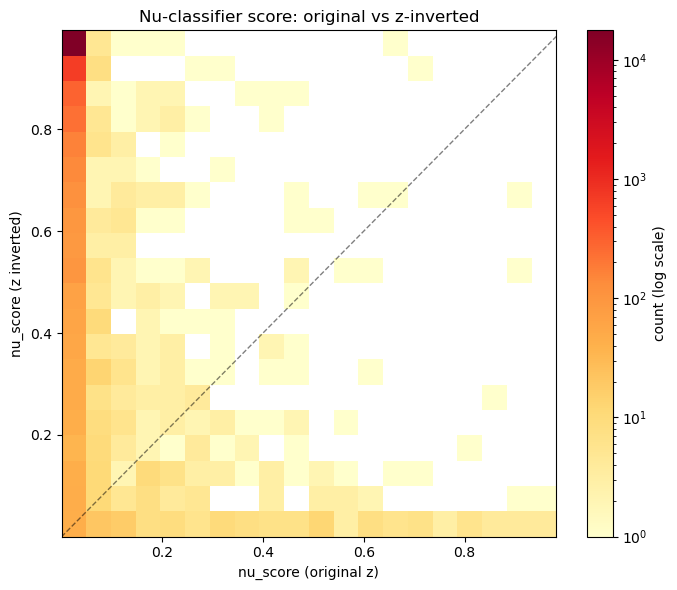

In [7]:
x = df_scores["nu_score"]
y = df_scores["nu_score_zinv"]

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(x, y, bins=20, norm=LogNorm(), cmap="YlOrRd")
plt.colorbar(h[3], ax=ax, label="count (log scale)")
ax.set_xlabel("nu_score (original z)")
ax.set_ylabel("nu_score (z inverted)")
ax.set_title("Nu-classifier score: original vs z-inverted")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)   # diagonal reference
plt.tight_layout()
plt.show()
